# Class Assignment 4: Distinguishing cats and dogs using CNN

In the last section we downloaded the files, looked at the directory structure, examined the images, and performed a variety of transforms in preparation for training.

In this section we'll define our model, then feed images through a training and validation sequence using DataLoader.

## Assignment
In this assignment,  you have to classify real images into either cats or dogs.

Sample code:  To help you get started,  there is already sample code inside my GitHub code under Deep Learning > Case Studies.

Before you begin:   If your computer does not have GPU, this assignment will take long time!   First try your PC first, if it does not work, switch to Google Colab.


1.  Download the "cat-dog" images in the Download section of TEAL.

2.  Load the images using built-in PyTorch datasets.ImageFolder.   You can also use glob if you want.

3.  Visualize some of the images and get a feeling what they are.   This will also teach you how to visualize image.

4.  Preprocess the images

First define the transforms:

train_transform = transforms.Compose([
transforms.RandomRotation(10), # rotate +/- 10 degrees
transforms.RandomHorizontalFlip(), # reverse 50% of images
transforms.Resize(224), # resize shortest side to 224 pixels
transforms.CenterCrop(224), # crop longest side to 224 pixels at center
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406],
[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
transforms.Resize(224),
transforms.CenterCrop(224),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406],
[0.229, 0.224, 0.225])
])

Notice the rotations and flip.  This is called "online augmentation".  It makes your model more robust.

Then, apply the transforms:

train_data = datasets.ImageFolder(os.path.join(root, 'train'), transform=train_transform)
test_data = datasets.ImageFolder(os.path.join(root, 'test'), transform=test_transform)

5.  Prepare your batch loader (batch size is up to you):

train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=True)

6. Design your network and train on it.  Make sure you understand all the shape thing.   In the exam, you have to figure this out by yourself.

7.  Perform test using the test set.  Report your accuracy, recall, precision, f1-score.

8.  Now do error analysis.   Learn to know how to get the images that are predicted wrong, and try to understand why your network cannot predict it.  Write a few sentence in your notebook reporting your observation.

9.   Now do inference.  Get 2-3 images from internet of cats and dogs.   See whether your model can predict well.   Write a few sentence in your notebook reporting your observation.

10.  Learn to do basic ablation study.   Compare no online augmentation vs. online augmentation.    Compare the metrics.   Report your observation with few sentence.

Enjoy!

# Assignment Understanding

1. Task: binary image classification (cats vs dogs).

2. Key ideas: images → tensors → neural network learns mapping to 2 classes.

3. Why use augmentation: instrinsic variability of real photos (rotation, flip, lighting). Augmentation reduces overfitting and increases robustness.

4. Why use pretrained models: transfer learning (ResNet, MobileNet) gives excellent performance quickly because early features (edges, textures) are reusable.

5. Evaluation: accuracy is useful, but precision/recall/F1 and confusion matrix tell which class is mispredicted more (important in imbalanced or safety-sensitive cases).

6. Error analysis: looking at misclassified images reveals model weaknesses (occlusion, unusual poses, small objects, background confusion).

7. Ablation study: compare versions with and without augmentation (or with/without fine-tuning) to measure improvement.

8. Since I am using Mac M4, I will be using MPS (MPS = Metal Performance Shaders (Apple’s GPU compute API).)

    To make sure you have GPU, you can either check system information and look for GPU numbers

    ```bash
        $ uname -m
        arm64
    ```
   If it prints:

    arm64 → Apple Silicon → GPU usable

    x86_64 → Intel Mac → GPU NOT usable for deep learning

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models # add models to the list
from torchvision.utils import make_grid
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

torch.__version__

'2.8.0'

In [50]:
# Enable GPU if available

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

device


device(type='mps')

# 1. Download the "cat-dog" images in the Download section of TEAL.

In [51]:
root = "../datasets/cat_dog"
train_dir = os.path.join(root, "train")
test_dir = os.path.join(root, "test")

train_dir, test_dir

('../datasets/cat_dog/train', '../datasets/cat_dog/test')


# 2. Load the images using built-in PyTorch datasets.ImageFolder.   You can also use glob if you want.

### Option 1: Use torchvision.datasets.ImageFolder

This is the recommended, easy method.

### Option 2: Use glob

This is “manual loading” — you find each file path using glob, then load images yourself (PIL, OpenCV, etc.).

Glob is useful if:

- The given data is not structured into class-named folders.

- Need to manually load and label images.

- Need more control. Like, Need to manually load images, custom structure, custom preprocessing

Example of using glob
```python

# Get all cat images
import glob

cat_paths = glob.glob("path/to/train/cats/*.jpg")
print(len(cat_paths))

# Get dog images
dog_paths = glob.glob("path/to/train/dogs/*.jpg")

# Load each manually
from PIL import Image

for path in cat_paths:
    img = Image.open(path)
    # preprocess manually here

```

We're going to take advantage of a built-in torchvision dataset tool called <a href='https://pytorch.org/docs/stable/torchvision/datasets.html#imagefolder'><tt><strong>ImageFolder</strong></tt></a>.

In [52]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.Resize(256),            # resize shortest side to 256
    transforms.CenterCrop(224),       # crop center 224x224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [53]:
batch_size = 32   # increase if you have GPU RAM
num_epochs = 8
number_of_workers = 4  # set to 0 if you are on Windows
seed = 42

In [54]:
# Datasets and Dataloaders
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
test_data  = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=number_of_workers, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=number_of_workers, pin_memory=True)

class_names = train_data.classes

print("Classes:", class_names)
print("Train size:", len(train_data), "Test size:", len(test_data))

Classes: ['cat', 'dog']
Train size: 18002 Test size: 6998



# 3. Visualize some of the images and get a feeling what they are. This will also teach you how to visualize image.

#### We can’t we just show the tensor directly. Because:

1. PyTorch tensors for images are usually shaped like `(C, H, W)` but matplotlib expects `(H, W, C)`. So you must transpose dimensions. Channel order is wrong (PyTorch uses CHW; matplotlib uses HWC)

2. PyTorch image tensors are normalized (values ≈ -1 to +1). plt.imshow() expects pixel values between 0 and 1 (or 0 to 255). So you need to undo normalization. 

Normalization formula:


$ \text{image}_{\text{norm}} = \frac{\text{image} - \text{mean}}{\text{std}} $


So , 

$ \text{image} = \text{std} * \text{image}_{\text{norm}} + \text{mean} $

5. Without conversion, the image appears:

    - Very dark

    - Colored incorrectly

    - Distorted or unrecognizable

    - Sometimes completely blank

Creating function to fix it.


In [55]:
# ---------- Quick visualization ----------
def imshow_tensor(img_tensor, title=None):
    img = img_tensor.cpu().numpy().transpose((1,2,0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    # Prevents weird artifacts if values go slightly outside range.
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title: plt.title(title)
    plt.axis('off')


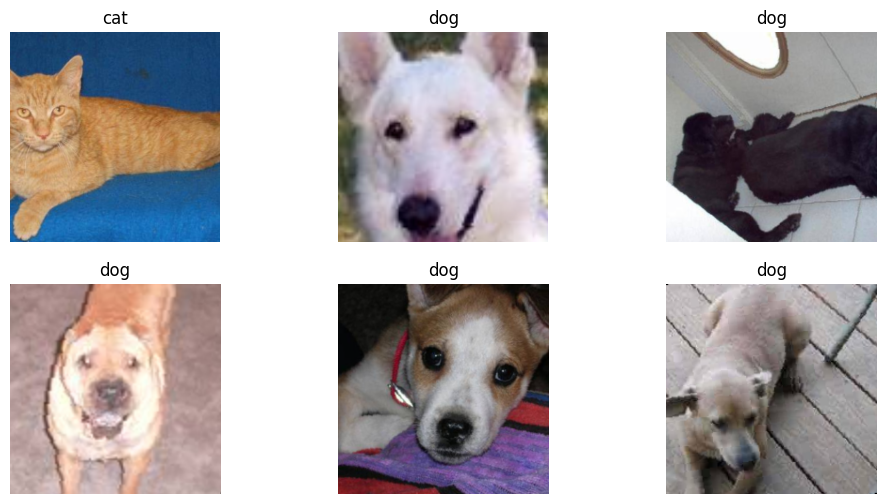

In [56]:
# show few training samples
imgs, labels = next(iter(DataLoader(train_data, batch_size=6, shuffle=True)))
plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    imshow_tensor(imgs[i], title=class_names[labels[i]])
plt.show()

# 4.  Preprocess the images

First define the transforms:
```python
train_transform = transforms.Compose([
transforms.RandomRotation(10), # rotate +/- 10 degrees
transforms.RandomHorizontalFlip(), # reverse 50% of images
transforms.Resize(224), # resize shortest side to 224 pixels
transforms.CenterCrop(224), # crop longest side to 224 pixels at center
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406],
[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
transforms.Resize(224),
transforms.CenterCrop(224),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406],
[0.229, 0.224, 0.225])
])
```

Notice the rotations and flip.  This is called "online augmentation".  It makes your model more robust.

Then, apply the transforms:

```python
train_data = datasets.ImageFolder(os.path.join(root, 'train'), transform=train_transform)
test_data = datasets.ImageFolder(os.path.join(root, 'test'), transform=test_transform)
```

Applied in second step.

# 5. Prepare your batch loader (batch size is up to you):

```python
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=True)
```

Applied in second step

# 6. Design your network and train on it.  Make sure you understand all the shape thing.   In the exam, you have to figure this out by yourself.


This includes:

1. shape of inputs

2. shape after transforms

3. shape after convolution layers

4. shape after pooling

5. shape after flatten

6. shape after linear layers

7. shape of logits

8. shape of labels


#### Why shape matters in CNN and MLPs

Every layer in a neural network expects inputs of a specific shape. If shapes don’t match, PyTorch throws an error:

```python
RuntimeError: mat1 and mat2 shapes cannot be multiplied
```

So understanding shapes is essential to design your own network.

## Understanding all shapes

### 0. Shapes in a typical cat/dog classifier

You use: Image size: 224 × 224

Color channels: 3 (RGB)

Batch size: B

So your input tensor shape is: `(B,3,224,224)`

This is the standard PyTorch format: `(batch, channels, height, width)`.

### 1. Input image shape

After transforms:

```python
transforms.Resize(224),
transforms.CenterCrop(224),
transforms.ToTensor(),
```

Your image shape becomes: (3,224,224)

With batch size B: (B,3,224,224)


### 2. Shape after a Convolution layer

```python
Example:

nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
```

Then shape becomes: (B,16,224,224)

General formula:

$\text{output height} = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1$

(H = height, P = padding, K = kernel, S = stride)


### 3. Shape after MaxPool

```python
Example:

nn.MaxPool2d(2)
```

This halves height & width: (B,16,112,112)


### 4. Shape after Flatten

Before feeding into a Linear layer, CNN outputs must be flattened.

If your last conv layer output is:
(B,64,7,7)

Flatten produces:
(B,64⋅7⋅7)=(B,3136)

This number must match the input dimension of your first Linear layer.

### 5. Linear Layer shape requirement (need to be careful)

If flatten gives 3136, then:
```python
nn.Linear(3136, 128)
```
is correct.

But if you accidentally write:
```python
nn.Linear(512, 128)
```

then your shapes will not match and you will get a runtime error.

### 6. Output logits shape

For binary classification (cat vs dog), output shape must be:
(B,2)
```python
Example:

nn.Linear(128, 2)
```

### 7. Label shape

Labels must be:
(B,)

Each label is 0 or 1.

In [57]:
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        ## nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1) # (B, 16, 224,224)
        self.pool  = nn.MaxPool2d(2)                # (B, 16,112,112)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)# (B, 32,112,112)
        self.pool2 = nn.MaxPool2d(2)                # (B, 32,56,56)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*56*56, 128)
        self.fc2 = nn.Linear(128, 84)
        self.fc3 = nn.Linear(84, 2)  # 2 classes: cat, dog

    def forward(self, x):
        x = F.relu(self.conv1(x))    
        x = self.pool2(x)   
        x = F.relu(self.conv2(x))    
        x = self.pool(x)    
        x = self.flatten(x)             
        x = F.relu(self.fc1(x))                 
        x = F.relu(self.fc2(x))                 
        x = self.fc3(x)                 
        return x


In [58]:
fake_input = torch.randn(1, 3, 224, 224, dtype=torch.float32)
conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, stride=1)
o = conv1(fake_input)
print(o.shape)

torch.Size([1, 6, 222, 222])


In [59]:
maxpool1 = F.max_pool2d(o, 2, 2)
print(maxpool1.shape)

torch.Size([1, 6, 111, 111])


In [60]:
conv2 = nn.Conv2d(6, 16, 3, 1)
o = conv2(maxpool1)
print(o.shape)

torch.Size([1, 16, 109, 109])


In [61]:
maxpool2 = F.max_pool2d(o, 2, 2)
print(maxpool2.shape)

torch.Size([1, 16, 54, 54])


## Training / Modeling
We'll start by using a model similar to the one we applied to the CIFAR-10 dataset, except that here we have a binary classification (2 output channels, not 10). Also, we'll add another set of convolution/pooling layers.

### Instantiate the model, define loss and optimization functions

In [62]:
torch.manual_seed(101)
CNNmodel  = ConvolutionalNeuralNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CNNmodel.parameters(), lr=0.001)
CNNmodel

ConvolutionalNeuralNetwork(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
)

### Looking at the trainable parameters

In [63]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>8}')
    print(f'________\n{sum(params):>8}')

In [64]:
count_parameters(CNNmodel)

     432
      16
    4608
      32
12845056
     128
   10752
      84
     168
       2
________
12861278


### Train the model

In the interests of time, we'll limit the number of training batches to 800, and the number of testing batches to 300. We'll train the model on 8000 of 18743 available images, and test it on 3000 out of 6251 images.

In [65]:
import time
start_time = time.time()

epochs = 3

max_trn_batch = 800
max_tst_batch = 300

train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for b, (X_train, y_train) in enumerate(train_loader):
        
        # Limit the number of batches
        if b == max_trn_batch:
            break
        b+=1
        
        # Apply the model
        y_pred = CNNmodel(X_train)
        loss = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print interim results
        if b%200 == 0:
            print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/8000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            # Limit the number of batches
            if b == max_tst_batch:
                break

            # Apply the model
            y_val = CNNmodel(X_test)

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)

print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed

epoch:  0  batch:  200 [  2000/8000]  loss: 0.58347851  accuracy: 192.650%
epoch:  0  batch:  400 [  4000/8000]  loss: 0.57919621  accuracy: 205.075%
epoch:  1  batch:  200 [  2000/8000]  loss: 0.58520502  accuracy: 237.700%
epoch:  1  batch:  400 [  4000/8000]  loss: 0.42350212  accuracy: 238.700%
epoch:  2  batch:  200 [  2000/8000]  loss: 0.50966728  accuracy: 250.900%
epoch:  2  batch:  400 [  4000/8000]  loss: 0.46498576  accuracy: 251.250%

Duration: 505 seconds


### Save the trained model

In [67]:
torch.save(CNNmodel.state_dict(), '../models/ca4/CNNmodel.pt')

# 7. Perform test using the test set.  Report your accuracy, recall, precision, f1-score.


In [68]:
train_losses = [loss.item() for loss in train_losses]
test_losses  = [loss.item() for loss in test_losses]

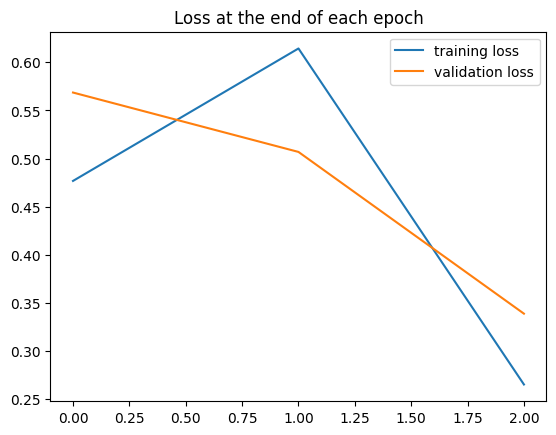

In [69]:
plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend();

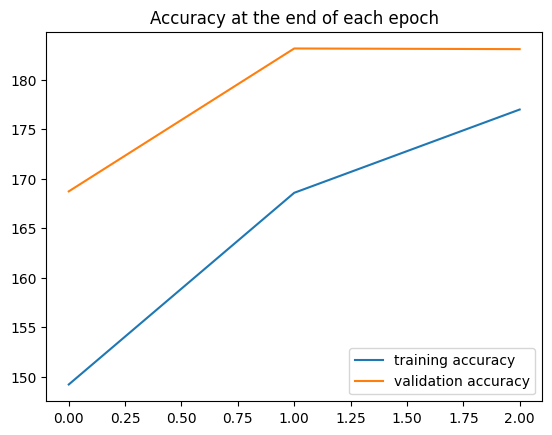

In [70]:
plt.plot([t/80 for t in train_correct], label='training accuracy')
plt.plot([t/30 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();

In [71]:
print(test_correct)
print(f'Test accuracy: {test_correct[-1].item()*100/3000:.3f}%')

[tensor(5062), tensor(5495), tensor(5493)]
Test accuracy: 183.100%


In [72]:
# Run once: requires scikit-learn installed
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, precision_recall_fscore_support

import torch
import numpy as np

CNNmodel.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        logits = CNNmodel(X)                    # raw logits
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Full classification report
print(classification_report(all_labels, all_preds, digits=4, zero_division=0))

# all metrics
prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
print(f"Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")


# Confusion matrix (useful to compute manual per-class precision/recall)
cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

              precision    recall  f1-score   support

           0     0.8506    0.6913    0.7627      3499
           1     0.7400    0.8785    0.8033      3499

    accuracy                         0.7849      6998
   macro avg     0.7953    0.7849    0.7830      6998
weighted avg     0.7953    0.7849    0.7830      6998

Precision: 0.7953, Recall: 0.7849, F1-score: 0.7830
Confusion matrix:
 [[2419 1080]
 [ 425 3074]]


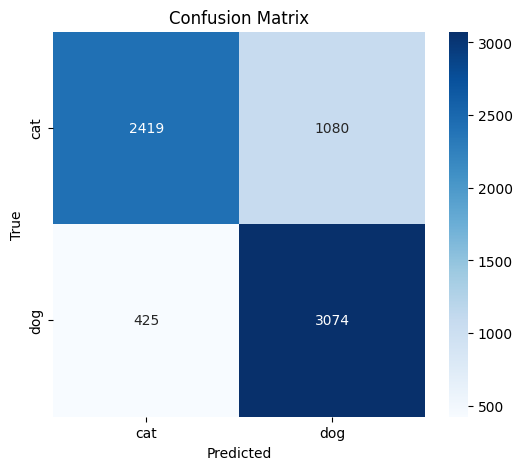

In [73]:
#Confusion heatmap
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



8.  Now do error analysis.   Learn to know how to get the images that are predicted wrong, and try to understand why your network cannot predict it.  Write a few sentence in your notebook reporting your observation.

9.   Now do inference.  Get 2-3 images from internet of cats and dogs.   See whether your model can predict well.   Write a few sentence in your notebook reporting your observation.

10.  Learn to do basic ablation study.   Compare no online augmentation vs. online augmentation.    Compare the metrics.   Report your observation with few sentence.

Enjoy!

## 3. Inference / Testing Evaluate model performance

In [80]:
# Preprocess & predict one image
from os import path
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as transforms

def predict_image(path, model, transform=test_transform):
    model.eval()
    img = Image.open(path).convert('RGB')
    inp = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(inp)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(probs)
    return class_names[pred], probs[pred]

root = "../datasets/cat_dog/inference"
external_images = ["cat1.png", "cat2.png", "dog1.png", "dog2.png"]

for filename in external_images:
    image_path = os.path.join(root, filename)
    pred, conf = predict_image(image_path, CNNmodel)
    print(filename, "->", pred, f"({conf:.3f})")


RuntimeError: Input type (MPSFloatType) and weight type (torch.FloatTensor) should be the same

## Part 2: Let's use a pretrained model!
Torchvision has a number of proven models available through <a href='https://pytorch.org/docs/stable/torchvision/models.html#classification'><tt><strong>torchvision.models</strong></tt></a>:
<ul>
<li><a href="https://arxiv.org/abs/1404.5997">AlexNet</a></li>
<li><a href="https://arxiv.org/abs/1409.1556">VGG</a></li>
<li><a href="https://arxiv.org/abs/1512.03385">ResNet</a></li>
<li><a href="https://arxiv.org/abs/1602.07360">SqueezeNet</a></li>
<li><a href="https://arxiv.org/abs/1608.06993">DenseNet</a></li>
<li><a href="https://arxiv.org/abs/1512.00567">Inception</a></li>
<li><a href="https://arxiv.org/abs/1409.4842">GoogLeNet</a></li>
<li><a href="https://arxiv.org/abs/1807.11164">ShuffleNet</a></li>
<li><a href="https://arxiv.org/abs/1801.04381">MobileNet</a></li>
<li><a href="https://arxiv.org/abs/1611.05431">ResNeXt</a></li>
</ul>
These have all been trained on the <a href='http://www.image-net.org/'>ImageNet</a> database of images. Our only task is to reduce the output of the fully connected layers from (typically) 1000 categories to just 2.

To access the models, you can construct a model with random weights by calling its constructor:<br>
<pre>resnet18 = models.resnet18()</pre>
You can also obtain a pre-trained model by passing pretrained=True:<br>
<pre>resnet18 = models.resnet18(pretrained=True)</pre>
All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

Feel free to investigate the different models available. Each one will be downloaded to a cache directory the first time they're accessed - from then on they'll be available locally.

For its simplicity and effectiveness, we'll use AlexNet:

In [15]:
AlexNetmodel = models.alexnet(pretrained=True)
AlexNetmodel

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /Users/chaklam/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:05<00:00, 46.1MB/s] 


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

<div class="alert alert-info">This model uses <a href='https://pytorch.org/docs/master/nn.html#torch.nn.AdaptiveAvgPool2d'><tt><strong>torch.nn.AdaptiveAvgPool2d(<em>output_size</em>)</strong></tt></a> to convert the large matrix coming out of the convolutional layers to a (6x6)x256 matrix being fed into the fully connected layers.</div>

### Freeze feature parameters
We want to freeze the pre-trained weights & biases. We set <tt>.requires_grad</tt> to False so we don't backprop through them.

In [16]:
for param in AlexNetmodel.parameters():
    param.requires_grad = False

### Modify the classifier
Next we need to modify the fully connected layers to produce a binary output. The section is labeled "classifier" in the AlexNet model.<br>
Note that when we assign new layers, their parameters default to <tt>.requires_grad=True</tt>.

In [17]:
torch.manual_seed(42)
AlexNetmodel.classifier = nn.Sequential(nn.Linear(9216, 1024),
                                 nn.ReLU(),
                                 nn.Dropout(0.4),
                                 nn.Linear(1024, 2),
                                 nn.LogSoftmax(dim=1))
AlexNetmodel

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, 

In [18]:
# These are the TRAINABLE parameters:
count_parameters(AlexNetmodel)

 9437184
    1024
    2048
       2
________
 9440258


### Define loss function & optimizer
We only want to optimize the classifier parameters, as the feature parameters are frozen.

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(AlexNetmodel.classifier.parameters(), lr=0.001)

### Train the model
Remember, we're only training the fully connected layers. The convolutional layers have fixed weights and biases. For this reason, we only need to run one epoch.

In [20]:
import time
start_time = time.time()

epochs = 1

max_trn_batch = 800
max_tst_batch = 300

train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for b, (X_train, y_train) in enumerate(train_loader):
        if b == max_trn_batch:
            break
        b+=1
        
        # Apply the model
        y_pred = AlexNetmodel(X_train)
        loss = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print interim results
        if b%200 == 0:
            print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/8000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            if b == max_tst_batch:
                break

            # Apply the model
            y_val = AlexNetmodel(X_test)

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)

print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed

epoch:  0  batch:  200 [  2000/8000]  loss: 1.21542966  accuracy:  88.800%
epoch:  0  batch:  400 [  4000/8000]  loss: 0.05259365  accuracy:  91.025%
epoch:  0  batch:  600 [  6000/8000]  loss: 0.17664188  accuracy:  91.567%
epoch:  0  batch:  800 [  8000/8000]  loss: 0.28487179  accuracy:  92.188%

Duration: 119 seconds


In [21]:
print(test_correct)
print(f'Test accuracy: {test_correct[-1].item()*100/3000:.3f}%')

[tensor(2808)]
Test accuracy: 93.600%


### Run a new image through the model
We can also pass a single image through the model to obtain a prediction.<br>
Pick a number from 0 to 6250, assign it to "x", and we'll use that value to select an image from the Cats and Dogs test set.

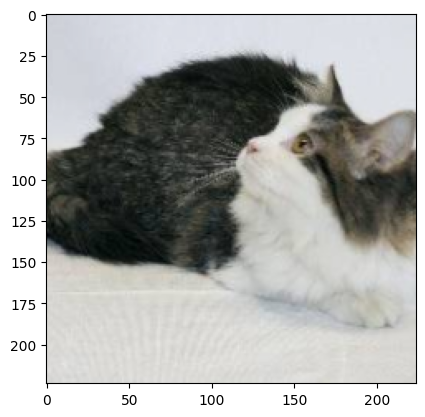

In [22]:
x = 2019
im = inv_normalize(test_data[x][0])
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

In [23]:
test_data[x][0].shape

torch.Size([3, 224, 224])

In [24]:
# CNN Model Prediction:

CNNmodel.eval()
with torch.no_grad():
    new_pred = CNNmodel(test_data[x][0].view(1,3,224,224)).argmax()
print(f'Predicted value: {new_pred.item()} {class_names[new_pred.item()]}')

Predicted value: 0 cat


In [25]:
# AlexNet Model Prediction:

AlexNetmodel.eval()
with torch.no_grad():
    new_pred = AlexNetmodel(test_data[x][0].view(1,3,224,224)).argmax()
print(f'Predicted value: {new_pred.item()} {class_names[new_pred.item()]}')

Predicted value: 0 cat
